In [1]:
import os
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
import os
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm
import matplotlib.pyplot as plt

BASE_PATH = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

print("Chemin dataset:", BASE_PATH)
print("Existe ?", os.path.exists(BASE_PATH))


Chemin dataset: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
Existe ? True


In [4]:
# Transformations d'entraînement
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomRotation(45),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transformations de validation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("✓ Transforms OK")


✓ Transforms OK


In [5]:
import os
import shutil

ORIG_BASE = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
WORK_BASE = "/kaggle/working/plantvillage_filtered"

# Copier le dataset une seule fois
if not os.path.exists(WORK_BASE):
    print("→ Copie du dataset dans /kaggle/working ...")
    shutil.copytree(os.path.join(ORIG_BASE, "train"), os.path.join(WORK_BASE, "train"))
    shutil.copytree(os.path.join(ORIG_BASE, "valid"), os.path.join(WORK_BASE, "valid"))
else:
    print("→ Dataset filtré existe déjà:", WORK_BASE)

# Classes à supprimer (exactement comme dans la liste que tu as affichée)
classes_to_remove = [
    'Blueberry___healthy',
    'Raspberry___healthy',
    'Soybean___healthy',
    'Squash___Powdery_mildew'
]

for split in ['train', 'valid']:
    split_path = os.path.join(WORK_BASE, split)
    for cls in classes_to_remove:
        cls_path = os.path.join(split_path, cls)
        if os.path.exists(cls_path):
            shutil.rmtree(cls_path)
            print("Supprimé:", cls_path)

# Nouveau BASE_PATH = dataset filtré
BASE_PATH = WORK_BASE
print("Nouveau BASE_PATH :", BASE_PATH)


→ Copie du dataset dans /kaggle/working ...
Supprimé: /kaggle/working/plantvillage_filtered/train/Blueberry___healthy
Supprimé: /kaggle/working/plantvillage_filtered/train/Raspberry___healthy
Supprimé: /kaggle/working/plantvillage_filtered/train/Soybean___healthy
Supprimé: /kaggle/working/plantvillage_filtered/train/Squash___Powdery_mildew
Supprimé: /kaggle/working/plantvillage_filtered/valid/Blueberry___healthy
Supprimé: /kaggle/working/plantvillage_filtered/valid/Raspberry___healthy
Supprimé: /kaggle/working/plantvillage_filtered/valid/Soybean___healthy
Supprimé: /kaggle/working/plantvillage_filtered/valid/Squash___Powdery_mildew
Nouveau BASE_PATH : /kaggle/working/plantvillage_filtered


In [8]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(os.path.join(BASE_PATH, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(BASE_PATH, "valid"), transform=val_transform)

print("Train classes:", len(train_dataset.classes))
print(train_dataset.classes)



Train classes: 34
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus

Train: 62940 | Val: 15734 | Classes: 34

DÉBUT ENTRAÎNEMENT

Epoch [1/30]


Validation: 100%|██████████| 492/492 [00:20<00:00, 23.63it/s]


  Train Loss: 2.1080 | Train Acc: 54.06%
  Val Loss  : 0.8478 | Val Acc  : 87.91%
  ✓ Modèle sauvegardé (Val Acc: 87.91%)

Epoch [2/30]


Validation: 100%|██████████| 492/492 [00:20<00:00, 23.72it/s]


  Train Loss: 0.8215 | Train Acc: 84.66%
  Val Loss  : 0.2884 | Val Acc  : 93.87%
  ✓ Modèle sauvegardé (Val Acc: 93.87%)

Epoch [3/30]


...

  Train Loss: 0.0800 | Train Acc: 97.81%
  Val Loss  : 0.0381 | Val Acc  : 98.79%
  ✓ Modèle sauvegardé (Val Acc: 98.79%)

Epoch [29/30]


Validation: 100%|██████████| 492/492 [00:20<00:00, 23.78it/s]


  Train Loss: 0.0816 | Train Acc: 97.73%
  Val Loss  : 0.0392 | Val Acc  : 98.77%

Epoch [30/30]


Validation: 100%|██████████| 492/492 [00:20<00:00, 23.48it/s]


  Train Loss: 0.0771 | Train Acc: 97.88%
  Val Loss  : 0.0378 | Val Acc  : 98.82%
  ✓ Modèle sauvegardé (Val Acc: 98.82%)

✓ Classes sauvegardées: 34


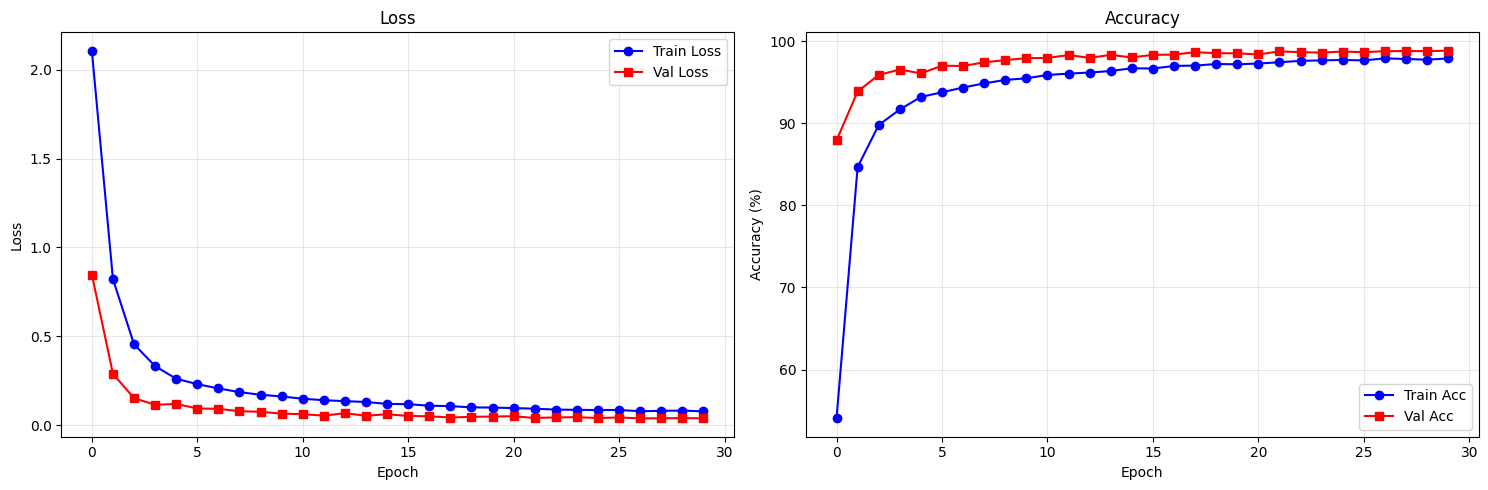

ENTRAÎNEMENT TERMINÉ
Meilleure Val Accuracy : 98.82%
Fichiers créés:
   best_plant_disease_model.pth
   class_names.json
   training_curves.png


In [9]:


# ============================================================
# CONFIGURATION
# ============================================================
CONFIG = {
    'num_classes': 34,
    'batch_size': 32,
    'num_epochs': 30,
    'learning_rate': 0.00005,
    'weight_decay': 5e-4,
    'device': 'cuda',
    'num_workers': 4,
}


BASE_PATH = "/kaggle/working/plantvillage_filtered"
BATCH_SIZE = CONFIG['batch_size']
NUM_EPOCHS = CONFIG['num_epochs']
DEVICE     = torch.device(CONFIG['device'])

# ============================================================
# TRANSFORMATIONS
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomRotation(45),  # ← AUGMENTÉ de 30 à 45°
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),  # ← NOUVEAU
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.15),  # ← AUGMENTÉ
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # ← NOUVEAU (translation)
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),  # ← NOUVEAU (flou)
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),  # ← NOUVEAU (perspective)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# ============================================================
# CHARGER LES DONNÉES
# ============================================================
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(BASE_PATH, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(BASE_PATH, "valid"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=CONFIG['num_workers'], pin_memory=True)

class_names = train_dataset.classes  # → 34 classes

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {len(class_names)}")

# ============================================================
# MODÈLE
# ============================================================

class PlantDiseaseClassifier(nn.Module):
    def __init__(self, num_classes=34):
        super().__init__()
        self.mobilenet = models.mobilenet_v2(pretrained=True)
        
        # Geler les premières couches pour éviter overfitting
        for param in self.mobilenet.features[:15].parameters():
            param.requires_grad = False
        
        in_features = self.mobilenet.classifier[1].in_features
        
        # Classifier amélioré avec plus de régularisation
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.4),  # ← AUGMENTÉ de 0.3 à 0.4
            nn.Linear(in_features, 256),  # ← Réduit de 512 à 256
            nn.BatchNorm1d(256),  # ← NOUVEAU (normalisation)
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 128),  # ← Couche supplémentaire pour plus de régularisation
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.mobilenet(x)

# ============================================================
# LOSS, OPTIMIZER, SCHEDULER
# ============================================================
# Instancier le modèle
model = PlantDiseaseClassifier(num_classes=CONFIG['num_classes']).to(DEVICE)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(),
                             lr=CONFIG['learning_rate'],
                             weight_decay=CONFIG['weight_decay'])

# Si tu gardes CosineAnnealingLR :
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['num_epochs'],
    eta_min=1e-6
)
# et dans la boucle : scheduler.step() (sans val_loss)


# OU alternative : StepLR
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# ============================================================
# FONCTIONS D'ENTRAÎNEMENT
# ============================================================

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        loss_sum += loss.item()
        _, pred = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()
    
    return loss_sum / len(loader), 100 * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    loss_sum = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss_sum += loss.item()
            _, pred = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
    
    return loss_sum / len(loader), 100 * correct / total

# ============================================================
# ENTRAÎNEMENT
# ============================================================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

print("\n" + "="*70)
print("DÉBUT ENTRAÎNEMENT")
print("="*70 + "\n")

for epoch in range(NUM_EPOCHS):
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.2f}%")
    
    scheduler.step()
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'class_names': class_names
        }, 'best_plant_disease_model.pth')
        print(f"  ✓ Modèle sauvegardé (Val Acc: {val_acc:.2f}%)")
    
    print()

# ============================================================
# SAUVEGARDER CLASS NAMES
# ============================================================

with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print(f"✓ Classes sauvegardées: {len(class_names)}")

# ============================================================
# GRAPHIQUES
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(history['val_loss'], 'r-s', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], 'b-o', label='Train Acc')
ax2.plot(history['val_acc'], 'r-s', label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# RÉSUMÉ FINAL
# ============================================================

print("="*70)
print("ENTRAÎNEMENT TERMINÉ")
print("="*70)
print(f"Meilleure Val Accuracy : {best_val_acc:.2f}%")
print(f"Fichiers créés:")
print(f"   best_plant_disease_model.pth")
print(f"   class_names.json")
print(f"   training_curves.png")
print("="*70)


In [11]:
print("Train acc (1er, dernier):", history['train_acc'][0], history['train_acc'][-1])
print("Val   acc (1er, dernier):", history['val_acc'][0], history['val_acc'][-1])
print("Best Val Acc:", best_val_acc)


Train acc (1er, dernier): 54.05624404194471 97.8805211312361
Val   acc (1er, dernier): 87.90517350959705 98.8242023643066
Best Val Acc: 98.8242023643066


In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdoumelkemi/tes-image")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/tes-image


In [7]:
import json
import torch
from torchvision import transforms, models
from PIL import Image

# Charger les classes
with open('/kaggle/input/best-plant-disease-model/pytorch/default/1/class_names (1).json', 'r') as f:
    class_names = json.load(f)

print(f"✓ Classes chargées: {len(class_names)}")


✓ Classes chargées: 34


In [1]:
import os
import shutil

ORIG_BASE = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
WORK_BASE = "/kaggle/working/plantvillage_filtered"

# Copier le dataset si pas déjà fait
if not os.path.exists(WORK_BASE):
    print("→ Copie du dataset dans /kaggle/working ...")
    shutil.copytree(os.path.join(ORIG_BASE, "train"), os.path.join(WORK_BASE, "train"))
    shutil.copytree(os.path.join(ORIG_BASE, "valid"), os.path.join(WORK_BASE, "valid"))
else:
    print("→ Dataset filtré existe déjà")

# Classes à supprimer
classes_to_remove = [
    'Blueberry___healthy',
    'Raspberry___healthy',
    'Soybean___healthy',
    'Squash___Powdery_mildew'
]

for split in ['train', 'valid']:
    split_path = os.path.join(WORK_BASE, split)
    for cls in classes_to_remove:
        cls_path = os.path.join(split_path, cls)
        if os.path.exists(cls_path):
            shutil.rmtree(cls_path)
            print("Supprimé:", cls_path)

# Vérifier
val_path = os.path.join(WORK_BASE, "valid")
print("Classes restantes:", len([d for d in os.listdir(val_path) if os.path.isdir(os.path.join(val_path, d))]))


→ Copie du dataset dans /kaggle/working ...
Supprimé: /kaggle/working/plantvillage_filtered/train/Blueberry___healthy
Supprimé: /kaggle/working/plantvillage_filtered/train/Raspberry___healthy
Supprimé: /kaggle/working/plantvillage_filtered/train/Soybean___healthy
Supprimé: /kaggle/working/plantvillage_filtered/train/Squash___Powdery_mildew
Supprimé: /kaggle/working/plantvillage_filtered/valid/Blueberry___healthy
Supprimé: /kaggle/working/plantvillage_filtered/valid/Raspberry___healthy
Supprimé: /kaggle/working/plantvillage_filtered/valid/Soybean___healthy
Supprimé: /kaggle/working/plantvillage_filtered/valid/Squash___Powdery_mildew
Classes restantes: 34


In [12]:
from torchvision import datasets, transforms
import torch
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# Même transform que pour la validation / test
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

VAL_BASE = "/kaggle/working/plantvillage_filtered/valid"

val_ds = datasets.ImageFolder(VAL_BASE, transform=val_transform)
print("Taille val_ds:", len(val_ds))
print("Nb classes:", len(val_ds.classes))
print("Premières classes:", val_ds.classes[:9])


Device: cuda
Taille val_ds: 15734
Nb classes: 34
Premières classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


In [8]:
import torch
from torchvision import models, transforms
import json
from PIL import Image

# Charger les classes
with open('/kaggle/input/best-plant-disease-model/pytorch/default/1/class_names (1).json', 'r') as f:
    class_names = json.load(f)

# Définir le modèle (même architecture)
class PlantDiseaseClassifier(torch.nn.Module):
    def __init__(self, num_classes=34):
        super().__init__()
        self.mobilenet = models.mobilenet_v2(pretrained=False)
        in_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = torch.nn.Sequential(
            torch.nn.Dropout(0.4),
            torch.nn.Linear(in_features, 256),
            torch.nn.BatchNorm1d(256),
            torch.nn.ReLU(inplace=True),
            torch.nn.Dropout(0.4),
            torch.nn.Linear(256, 128),
            torch.nn.BatchNorm1d(128),
            torch.nn.ReLU(inplace=True),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.mobilenet(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PlantDiseaseClassifier(num_classes=34).to(device)

# Charger le checkpoint
checkpoint = torch.load('/kaggle/input/best-plant-disease-model/pytorch/default/1/best_plant_disease_model (3).pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f" Modèle rechargé (Val Acc: {checkpoint['val_acc']:.2f}%)")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


 Modèle rechargé (Val Acc: 98.82%)



TEST SUR UNE IMAGE DE LA VALIDATION
Classe réelle   : Apple___Apple_scab
Classe prédite  : Apple___Apple_scab
Confiance       : 99.95%


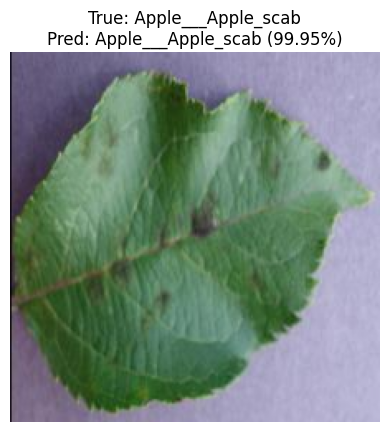

In [16]:
# Prendre une image de la validation
img_tensor, true_label = val_ds[0]  # première image
true_class = val_ds.classes[true_label]  # ← CORRIGÉ : pas .dataset

img_batch = img_tensor.unsqueeze(0).to(device)

model.to(device)
model.eval()

with torch.no_grad():
    output = model(img_batch)
    probs = torch.nn.functional.softmax(output, dim=1)
    conf, pred = torch.max(probs, 1)

pred_class = class_names[pred.item()]
conf_score = conf.item()

print("\n" + "="*70)
print("TEST SUR UNE IMAGE DE LA VALIDATION")
print("="*70)
print("Classe réelle   :", true_class)
print("Classe prédite  :", pred_class)
print("Confiance       :", f"{conf_score:.2%}")
print("="*70)

# Afficher l'image (dénormalisation pour visualisation)
img_show = img_tensor.permute(1, 2, 0).cpu().numpy()
img_show = (img_show * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
img_show = img_show.clip(0, 1)

import matplotlib.pyplot as plt
plt.imshow(img_show)
plt.title(f"True: {true_class}\nPred: {pred_class} ({conf_score:.2%})")
plt.axis('off')
plt.show()


In [13]:
import random

test_results = []
for i in range(10):
    idx = random.randint(0, len(val_ds) - 1)
    img_tensor, true_label = val_ds[idx]
    true_class = val_ds.classes[true_label]
    
    img_batch = img_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(img_batch)
        probs = torch.nn.functional.softmax(output, dim=1)
        conf, pred = torch.max(probs, 1)
    
    pred_class = class_names[pred.item()]
    conf_score = conf.item()
    
    test_results.append({
        'true': true_class,
        'pred': pred_class,
        'confidence': conf_score,
        'correct': pred_class == true_class
    })

# Afficher résultats
for r in test_results[:9]:
    print(f"True: {r['true']:<40} | Pred: {r['pred']:<40} | Conf: {r['confidence']:.2%} | {'✅' if r['correct'] else '❌'}")


True: Potato___Late_blight                     | Pred: Potato___Late_blight                     | Conf: 99.89% | ✅
True: Corn_(maize)___Northern_Leaf_Blight      | Pred: Corn_(maize)___Northern_Leaf_Blight      | Conf: 99.84% | ✅
True: Apple___Cedar_apple_rust                 | Pred: Apple___Cedar_apple_rust                 | Conf: 99.97% | ✅
True: Strawberry___healthy                     | Pred: Strawberry___healthy                     | Conf: 99.95% | ✅
True: Potato___healthy                         | Pred: Potato___healthy                         | Conf: 99.91% | ✅
True: Strawberry___Leaf_scorch                 | Pred: Strawberry___Leaf_scorch                 | Conf: 99.99% | ✅
True: Grape___Leaf_blight_(Isariopsis_Leaf_Spot) | Pred: Grape___Leaf_blight_(Isariopsis_Leaf_Spot) | Conf: 99.97% | ✅
True: Apple___Apple_scab                       | Pred: Apple___Apple_scab                       | Conf: 99.75% | ✅
True: Tomato___Tomato_Yellow_Leaf_Curl_Virus   | Pred: Tomato___Tomato_Yello

In [15]:
def predict_plant_disease(image_path, threshold=0.70):
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.nn.functional.softmax(output, dim=1)
        confidence, pred = torch.max(probs, 1)
    
    confidence_score = confidence.item()
    predicted_class = class_names[pred.item()]
    
    if confidence_score < threshold:
        return {
            "status": "uncertain",
            "message": "Image hors du domaine connu",
            "confidence": confidence_score
        }
    else:
        return {
            "status": "success",
            "class": predicted_class,
            "confidence": confidence_score
        }


In [2]:
# Cloner le repository PlantDoc
!git clone https://github.com/pratikkayal/PlantDoc-Dataset.git

# Vérifier la structure
import os

PLANTDOC_PATH = "/kaggle/working/PlantDoc-Dataset/Cropped-PlantDoc"

print("Chemin:", PLANTDOC_PATH)
print("Existe ?:", os.path.exists(PLANTDOC_PATH))

if os.path.exists(PLANTDOC_PATH):
    classes = [d for d in os.listdir(PLANTDOC_PATH) if os.path.isdir(os.path.join(PLANTDOC_PATH, d))]
    print(f"\nNombre de classes: {len(classes)}")
    print("Classes:", classes[:5])


Cloning into 'PlantDoc-Dataset'...
remote: Enumerating objects: 2670, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 2670 (delta 22), reused 22 (delta 22), pack-reused 2635 (from 1)
Receiving objects: 100% (2670/2670), 932.92 MiB | 55.18 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (2581/2581), done.
Chemin: /kaggle/working/PlantDoc-Dataset/Cropped-PlantDoc
Existe ?: False


In [3]:
from torchvision import datasets, transforms
import torch.nn.functional as F

PLANTDOC_PATH = "/kaggle/working/PlantDoc-Dataset/train"

plantdoc_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

plantdoc_dataset = datasets.ImageFolder(PLANTDOC_PATH, transform=plantdoc_transform)

print(f"Total PlantDoc images: {len(plantdoc_dataset)}")
print(f"PlantDoc classes: {len(plantdoc_dataset.classes)}")
print("Premières classes:", plantdoc_dataset.classes[:5])


Total PlantDoc images: 2342
PlantDoc classes: 28
Premières classes: ['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf', 'Bell_pepper leaf spot']


In [5]:
def get_plant_from_plantdoc_label(label: str):
    # ex: "Tomato leaf bacterial spot" -> "Tomato"
    return label.split(' ')[0]

def get_plant_from_plantvillage_label(label: str):
    # ex: "Tomato___Late_blight" -> "Tomato"
    return label.split('___')[0]


In [6]:
import random

model.to(device)
model.eval()

results = []
correct_plant = 0
total = 0

N = 100  # nombre d'images à tester (tu peux augmenter à 200–300 si temps)

for i in range(min(N, len(plantdoc_dataset))):
    img_tensor, true_label = plantdoc_dataset[i]
    true_full_label = plantdoc_dataset.classes[true_label]          # ex: "Tomato leaf bacterial spot"
    true_plant = get_plant_from_plantdoc_label(true_full_label)     # ex: "Tomato"
    
    img_batch = img_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(img_batch)
        probs = F.softmax(output, dim=1)
        conf, pred = torch.max(probs, 1)
    
    pred_full_label = class_names[pred.item()]                       # ex: "Tomato___Late_blight"
    pred_plant = get_plant_from_plantvillage_label(pred_full_label)  # ex: "Tomato"
    conf_score = conf.item()
    
    is_plant_ok = (true_plant == pred_plant)
    
    results.append({
        "true_label": true_full_label,
        "true_plant": true_plant,
        "pred_label": pred_full_label,
        "pred_plant": pred_plant,
        "confidence": conf_score,
        "plant_ok": is_plant_ok,
    })
    
    if is_plant_ok:
        correct_plant += 1
    total += 1

print("\n" + "="*70)
print("RÉSULTATS SUR PLANTDOC (N =", total, "images)")
print("="*70)
print(f"Accuracy plante (ignorer maladie) : {correct_plant}/{total} = {correct_plant/total:.2%}")
print(f"Confiance moyenne : {sum(r['confidence'] for r in results)/len(results):.2%}")
print("="*70)

print("\nExemples :")
for r in results[:10]:
    status = "✅" if r["plant_ok"] else "❌"
    print(f"{status} True: {r['true_label']:<40} | Pred: {r['pred_label']:<40} | Plant: {r['true_plant']} vs {r['pred_plant']} | Conf: {r['confidence']:.2%}")


NameError: name 'model' is not defined

Partie Finetuning

In [7]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import os

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Chemins
PLANTDOC_PATH = "/kaggle/working/PlantDoc-Dataset/train"
BEST_MODEL_PATH = "/kaggle/input/best-plant-disease-model/pytorch/default/1/best_plant_disease_model (3).pth"  # ton modèle PlantVillage

# Transformations (mêmes que PlantVillage)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Charger PlantDoc
plantdoc_dataset = datasets.ImageFolder(PLANTDOC_PATH, transform=transform)
print(f"PlantDoc: {len(plantdoc_dataset)} images, {len(plantdoc_dataset.classes)} classes")

# DataLoader
BATCH_SIZE = 32
plantdoc_loader = DataLoader(plantdoc_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)

# Nombre de classes PlantDoc
num_plantdoc_classes = len(plantdoc_dataset.classes)
print(f"Nombre de classes PlantDoc: {num_plantdoc_classes}")  # devrait être 28


Device: cuda
PlantDoc: 2342 images, 28 classes
Nombre de classes PlantDoc: 28


In [8]:
# Définir la classe du modèle (même architecture)
class PlantDiseaseClassifier(nn.Module):
    def __init__(self, num_classes=34):
        super().__init__()
        self.mobilenet = models.mobilenet_v2(pretrained=False)
        in_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.mobilenet(x)

# Charger le modèle PlantVillage
model = PlantDiseaseClassifier(num_classes=34).to(device)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

# Geler les premières couches (features extraction)
for param in model.mobilenet.features[:15].parameters():
    param.requires_grad = False

# Créer un NOUVEAU classifier pour PlantDoc (28 classes)
in_features = model.mobilenet.classifier[1].in_features  # 1280

model.mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, num_plantdoc_classes)  # 28 classes
).to(device)

print("✅ Modèle adapté pour PlantDoc")
print(f"Nouveau classifier: 34 → {num_plantdoc_classes} classes")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Modèle adapté pour PlantDoc
Nouveau classifier: 34 → 28 classes


In [9]:
# Optimizer
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.00001,
    weight_decay=5e-4
)

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10,
    eta_min=1e-7
)

# Loss
criterion = nn.CrossEntropyLoss()

# Config
NUM_EPOCHS = 10
BATCH_SIZE = 32

print("✅ Configuration prête")


✅ Configuration prête


In [12]:
# ============================================
# SECTION 3 : Configuration (CORRECTED)
# ============================================
# Dégeler seulement 5 premières couches (beaucoup plus agressif)
for param in model.mobilenet.features[:5].parameters():
    param.requires_grad = False

# Optimizer SGD (mieux pour fine-tuning profond)
optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001,  # 10x plus grand
    momentum=0.9,
    weight_decay=5e-4
)

# Scheduler avec warm-up
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01,
    steps_per_epoch=len(plantdoc_loader),
    epochs=10
)

# Config
NUM_EPOCHS = 10
BATCH_SIZE = 32



print("✅ Configuration corrigée (lr=0.0001, 10 epochs, 10 couches gelées)")

# ============================================
# SECTION 4 : Boucle d'entraînement (inchangée)
# ============================================
history = {'train_loss': [], 'train_acc': []}
best_acc = 0.0

print("\n" + "="*70)
print("DÉBUT FINE-TUNING SUR PLANTDOC (CORRECTED)")
print("="*70 + "\n")

for epoch in range(NUM_EPOCHS):
    model.train()
    loss_sum = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(plantdoc_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}')
    
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        loss_sum += loss.item()
        _, pred = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})
    
    epoch_loss = loss_sum / len(plantdoc_loader)
    epoch_acc = 100 * correct / total
    
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    
    scheduler.step()
    
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} : Loss {epoch_loss:.4f} | Acc {epoch_acc:.2f}%")
    
    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_acc': epoch_acc,
            'plantdoc_classes': plantdoc_dataset.classes
        }, 'best_plantdoc_model.pth')
        print(f"  ✅ Meilleur modèle sauvegardé (Acc: {epoch_acc:.2f}%)")

print("\n" + "="*70)
print("FINE-TUNING TERMINÉ")
print(f"Meilleure accuracy : {best_acc:.2f}%")
print("="*70)


✅ Configuration corrigée (lr=0.0001, 10 epochs, 10 couches gelées)

DÉBUT FINE-TUNING SUR PLANTDOC (CORRECTED)



Epoch 1/10: 100%|██████████| 74/74 [00:25<00:00,  2.93it/s, loss=2.2726, acc=64.82%]



Epoch 1/10 : Loss 1.2594 | Acc 64.82%
  ✅ Meilleur modèle sauvegardé (Acc: 64.82%)


Epoch 2/10: 100%|██████████| 74/74 [00:24<00:00,  3.02it/s, loss=2.5369, acc=66.74%]



Epoch 2/10 : Loss 1.1792 | Acc 66.74%
  ✅ Meilleur modèle sauvegardé (Acc: 66.74%)


...


Epoch 8/10 : Loss 0.7091 | Acc 82.24%
  ✅ Meilleur modèle sauvegardé (Acc: 82.24%)


Epoch 9/10: 100%|██████████| 74/74 [00:25<00:00,  2.88it/s, loss=1.6186, acc=82.37%]



Epoch 9/10 : Loss 0.6785 | Acc 82.37%
  ✅ Meilleur modèle sauvegardé (Acc: 82.37%)


Epoch 10/10: 100%|██████████| 74/74 [00:26<00:00,  2.81it/s, loss=1.0860, acc=85.23%]


Epoch 10/10 : Loss 0.5834 | Acc 85.23%
  ✅ Meilleur modèle sauvegardé (Acc: 85.23%)

FINE-TUNING TERMINÉ
Meilleure accuracy : 85.23%


In [13]:
# Charger le modèle fine-tuné
checkpoint_plantdoc = torch.load('best_plantdoc_model.pth', map_location=device)
model.load_state_dict(checkpoint_plantdoc['model_state_dict'])
model.eval()

# Tester sur 20 images
plantdoc_classes = checkpoint_plantdoc['plantdoc_classes']

print("\n" + "="*50)
print("TEST FINAL SUR PLANTDOC")
print("="*50)

correct = 0
for i in range(20):
    img_tensor, label = plantdoc_dataset[i]
    img_batch = img_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(img_batch)
        probs = F.softmax(output, dim=1)
        conf, pred = torch.max(probs, 1)
    
    pred_class = plantdoc_classes[pred.item()]
    true_class = plantdoc_classes[label]
    
    if pred_class == true_class:
        correct += 1
    
    print(f"True: {true_class:<40} | Pred: {pred_class:<40} | Conf: {conf.item():.2%}")

print(f"\nAccuracy sur 20 images : {correct}/20 = {correct/20:.2%}")



TEST FINAL SUR PLANTDOC
True: Apple Scab Leaf                          | Pred: Apple Scab Leaf                          | Conf: 97.87%
True: Apple Scab Leaf                          | Pred: Apple Scab Leaf                          | Conf: 83.06%
True: Apple Scab Leaf                          | Pred: Apple Scab Leaf                          | Conf: 64.96%
True: Apple Scab Leaf                          | Pred: Apple Scab Leaf                          | Conf: 96.53%
True: Apple Scab Leaf                          | Pred: Apple Scab Leaf                          | Conf: 91.58%
True: Apple Scab Leaf                          | Pred: Apple Scab Leaf                          | Conf: 89.82%
True: Apple Scab Leaf                          | Pred: Apple Scab Leaf                          | Conf: 76.47%
True: Apple Scab Leaf                          | Pred: Apple Scab Leaf                          | Conf: 95.12%
True: Apple Scab Leaf                          | Pred: Apple Scab Leaf                 

Device : cuda
 Modèle PlantDoc chargé : 28 classes
 Modèle chargé correctement

 Test sur PlantDoc (validation)...


 Image : tomato-late-blight.jpg
 Prédiction : Tomato leaf late blight
 Confiance : 58.90%
  Prédiction fiable

Top 3 :
  1. Tomato leaf late blight                  58.90%
  2. Tomato Early blight leaf                 29.93%
  3. Tomato leaf bacterial spot               2.88%


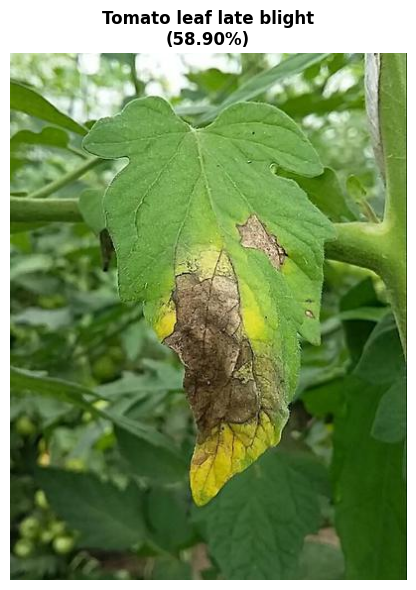


 Image : tomato__Early_blight.jpg
 Prédiction : Tomato Early blight leaf
 Confiance : 74.26%
  Prédiction fiable

Top 3 :
  1. Tomato Early blight leaf                 74.26%
  2. Potato leaf early blight                 13.10%
  3. Tomato Septoria leaf spot                4.69%


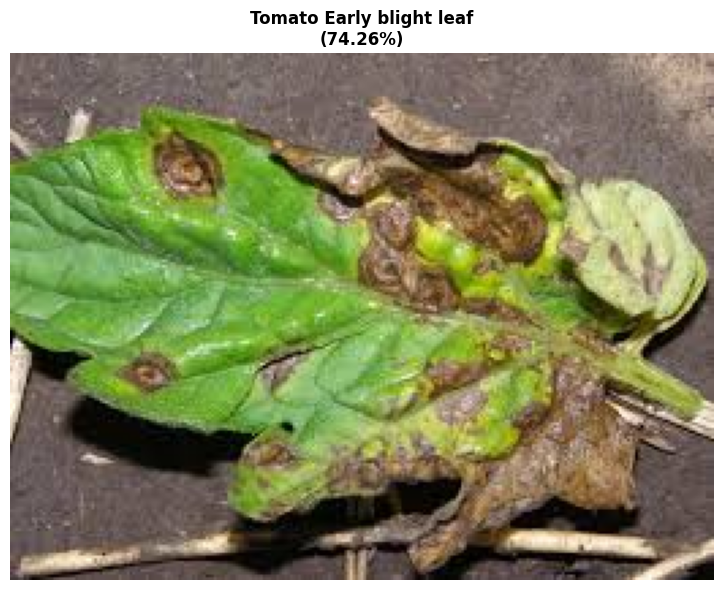


 Image : Tomato-blight-leaf.jpg
 Prédiction : Tomato leaf late blight
 Confiance : 67.84%
  Prédiction fiable

Top 3 :
  1. Tomato leaf late blight                  67.84%
  2. Potato leaf late blight                  13.82%
  3. Tomato mold leaf                         10.14%


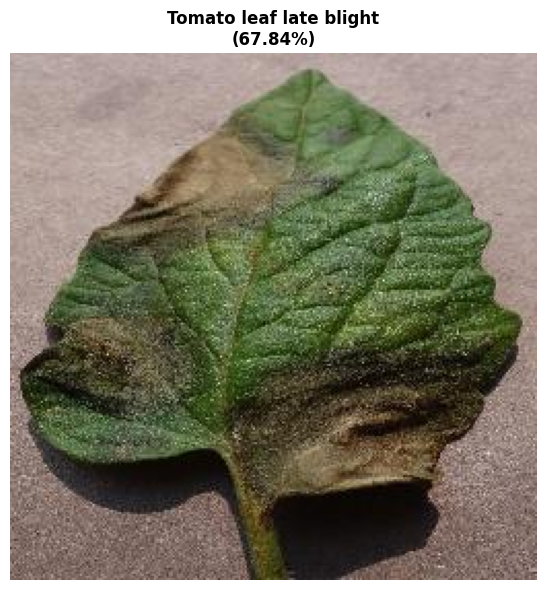


 Image : tomato-blight-leaf.png
 Prédiction : Tomato leaf late blight
 Confiance : 50.02%
  Prédiction fiable

Top 3 :
  1. Tomato leaf late blight                  50.02%
  2. Tomato Early blight leaf                 20.78%
  3. Potato leaf late blight                  12.68%


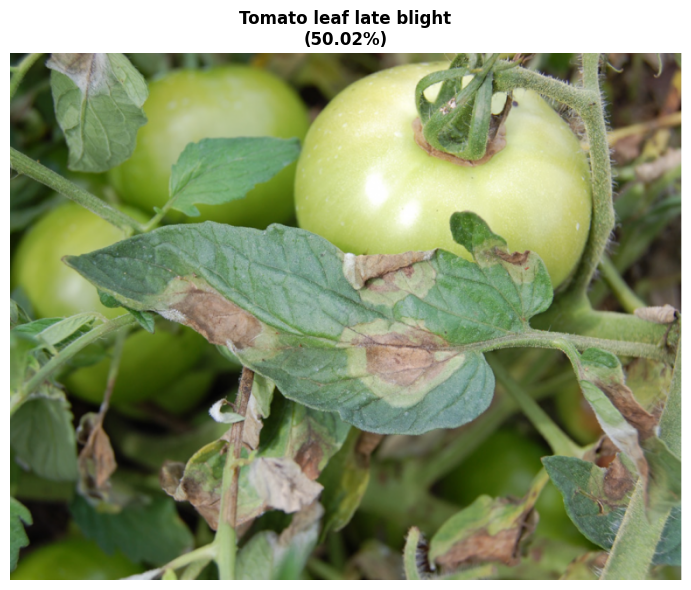


 Image : tomato-late-blight-test.jpg
 Prédiction : Tomato leaf late blight
 Confiance : 58.90%
  Prédiction fiable

Top 3 :
  1. Tomato leaf late blight                  58.90%
  2. Tomato Early blight leaf                 29.93%
  3. Tomato leaf bacterial spot               2.88%


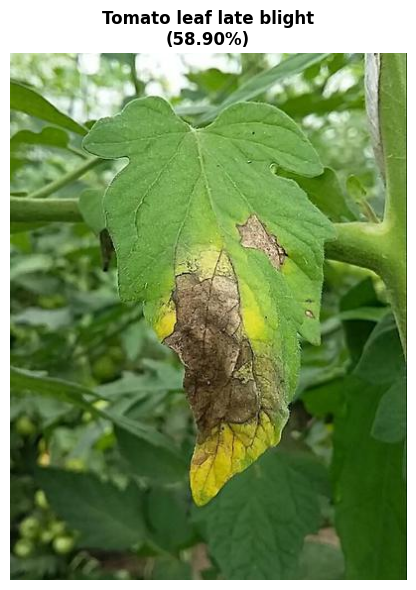


 Image : Tomato-Leaf-Curl.webp
 Prédiction : Tomato leaf yellow virus
 Confiance : 80.54%
  Prédiction fiable

Top 3 :
  1. Tomato leaf yellow virus                 80.54%
  2. Tomato leaf mosaic virus                 17.69%
  3. Tomato leaf bacterial spot               0.39%


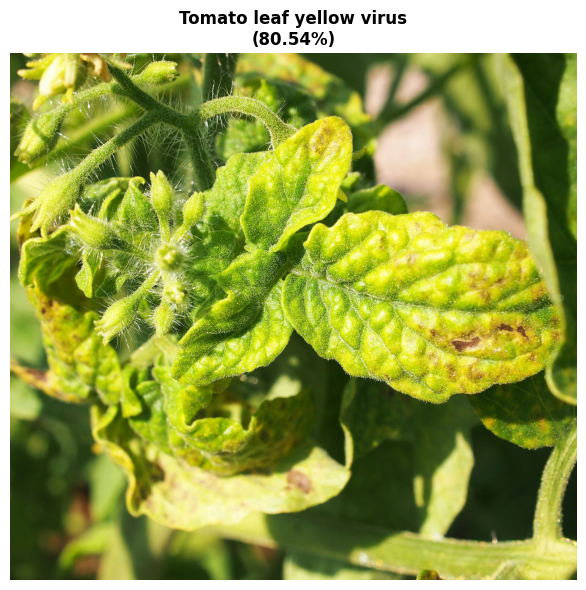


 Tests terminés !


In [20]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import json

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

# Charger le checkpoint PlantDoc
checkpoint_plantdoc = torch.load('best_plantdoc_model.pth', map_location=device)
plantdoc_classes = checkpoint_plantdoc['plantdoc_classes']

print(f" Modèle PlantDoc chargé : {len(plantdoc_classes)} classes")

# Créer le modèle avec l'architecture PlantDoc (28 classes)
class PlantDiseaseClassifier(nn.Module):
    def __init__(self, num_classes=28):
        super().__init__()
        self.mobilenet = models.mobilenet_v2(pretrained=False)
        in_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 512),  # ← 512 (PlantDoc)
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 256),          # ← 256 (PlantDoc)
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)   # ← 28 (PlantDoc)
        )
    def forward(self, x):
        return self.mobilenet(x)

# Charger le modèle
model = PlantDiseaseClassifier(num_classes=28).to(device)
model.load_state_dict(checkpoint_plantdoc['model_state_dict'])
model.eval()

print(" Modèle chargé correctement")

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Fonction de prédiction
def predict_image(image_path, threshold=0.50):
    if not os.path.exists(image_path):
        print(f" Image non trouvée : {image_path}")
        return
    
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(image_tensor)
        probs = nn.functional.softmax(output, dim=1)
        confidence, pred = torch.max(probs, 1)
    
    confidence_score = confidence.item()
    predicted_class = plantdoc_classes[pred.item()]
    
    print("\n" + "="*70)
    print(f" Image : {os.path.basename(image_path)}")
    print(f" Prédiction : {predicted_class}")
    print(f" Confiance : {confidence_score:.2%}")
    print("="*70)
    
    if confidence_score < threshold:
        print("  Image incertaine ou hors domaine")
    else:
        print("  Prédiction fiable")
    
    # Top 3 prédictions
    top3_prob, top3_idx = torch.topk(probs, 3)
    print("\nTop 3 :")
    for i, (prob, idx) in enumerate(zip(top3_prob[0], top3_idx[0]), 1):
        print(f"  {i}. {plantdoc_classes[idx.item()]:<40} {prob.item():.2%}")
    
    # Afficher l'image
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(f"{predicted_class}\n({confidence_score:.2%})", fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# ============================================
# TESTER AVEC TES IMAGES
# ============================================

# Exemple : tester une image du dataset PlantDoc
print("\n Test sur PlantDoc (validation)...\n")

# Ou tester avec tes images uploadées
image_paths = [
    '/kaggle/input/tomato/tomato-late-blight.jpg',
    '/kaggle/input/tomato-early-blight2/tomato__Early_blight.jpg',
    '/kaggle/input/tomatos/Tomato-blight-leaf.jpg',
    '/kaggle/input/tomato-late-blight/tomato-blight-leaf.png',
    '/kaggle/input/tes-image/tomato-late-blight-test.jpg',
    '/kaggle/input/tomato-leaf-curl/Tomato-Leaf-Curl.webp'
]

for path in image_paths:
    predict_image(path, threshold=0.50)

print("\n Tests terminés !")


In [19]:
print(len(plantdoc_dataset.classes))
for c in plantdoc_dataset.classes:
    print(c)


28
Apple Scab Leaf
Apple leaf
Apple rust leaf
Bell_pepper leaf
Bell_pepper leaf spot
Blueberry leaf
Cherry leaf
Corn Gray leaf spot
Corn leaf blight
Corn rust leaf
Peach leaf
Potato leaf early blight
Potato leaf late blight
Raspberry leaf
Soyabean leaf
Squash Powdery mildew leaf
Strawberry leaf
Tomato Early blight leaf
Tomato Septoria leaf spot
Tomato leaf
Tomato leaf bacterial spot
Tomato leaf late blight
Tomato leaf mosaic virus
Tomato leaf yellow virus
Tomato mold leaf
Tomato two spotted spider mites leaf
grape leaf
grape leaf black rot
